In [3]:
import os
from PIL import Image

In [4]:
benign_path=r"C:\Users\Kannan\Desktop\QR_MODEL1_SE_PROJECT\QR_codes\benign\benign"
mal_path=r"C:\Users\Kannan\Desktop\QR_MODEL1_SE_PROJECT\QR_codes\malicious\malicious"

for root, dirs, files in os.walk(benign_path):
    bimg_files=[f for f in files if f.endswith((".png",".jpg",".jpeg"))]

for root, dirs, files in os.walk(mal_path):
    mimg_files=[f for f in files if f.endswith((".png",".jpg",".jpeg"))]

print(len(bimg_files))
print(len(mimg_files))

100000
100000


In [5]:
import random
import matplotlib.pyplot as plt

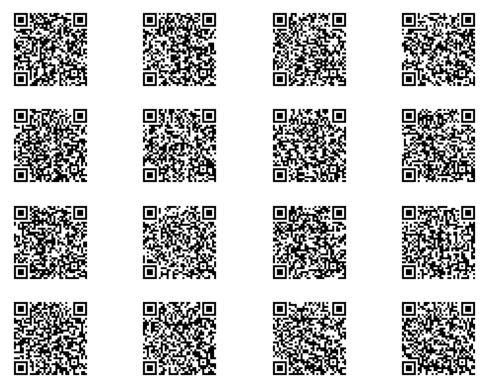

In [6]:
bimages=os.listdir(benign_path)
for i in range(16):
    img=random.choice(bimages)
    img_path=os.path.join(benign_path,img)
    bimg=Image.open(img_path)
    plt.subplot(4,4,i+1)
    plt.imshow(bimg)
    plt.axis("off")


In [7]:
from pyzbar.pyzbar import decode

In [8]:
def extract_url(img_path):
    try:
        img=Image.open(img_path)
        result=decode(img)
        if len(result)>0:
            return result[0].data.decode("utf-8")
        return None
    except:
        return None

In [9]:
dataset=[]
benign_files=os.listdir(benign_path)[:10000]
mal_files=os.listdir(mal_path)[:10000]
for file in benign_files:
    path=os.path.join(benign_path,file)
    url=extract_url(path)
    
    if url:
        dataset.append(
            {
                "url":url,
                "label":0
            }
        )

for file in mal_files:
    url=extract_url(os.path.join(mal_path,file))
    if url:
        dataset.append({
            "url":url,
            "label":1
        })

In [10]:
import pandas as pd

In [11]:
df=pd.DataFrame(dataset)
print(df.shape)

(20000, 2)


In [12]:
df.head(10)

,url,label
0,"0 https://www.google.com\nName: url, dtype:...",0
1,"1 https://www.youtube.com\nName: url, dtype...",0
2,"10 https://www.taobao.com\nName: url, dtype...",0
3,"100 https://www.google.com.sa\nName: url, d...",0
4,1000 https://www.en.wikipedia.org/wiki/Bill...,0
5,10000 https://www.en.wikipedia.org/wiki/Sou...,0
6,10001 https://www.en.wikipedia.org/wiki/Sou...,0
7,10002 https://www.en.wikipedia.org/wiki/Sou...,0
8,10003 https://www.en.wikipedia.org/wiki/Sou...,0
9,10004 https://www.en.wikipedia.org/wiki/Sou...,0


In [13]:
df["label"].value_counts()

label
0    10000
1    10000
Name: count, dtype: int64

In [15]:
!pip install transformers==4.52.4 

In [14]:
import transformers

c:\Users\Kannan\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification
)

In [16]:
model_name="google/mobilebert-uncased"
tokenizer=AutoTokenizer.from_pretrained(model_name)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
traint,testt,trainl,testl=train_test_split(
    df["url"],
    df["label"],
    test_size=0.2,
    random_state=32,
    stratify=df["label"]
)

In [19]:
train_encodings=tokenizer(
    traint.to_list(),
    padding=True,
    truncation=True,
    max_length=128
)

test_encodings=tokenizer(
    testt.to_list(),
    padding=True,
    truncation=True,
    max_length=128
)

In [20]:
df.to_csv(
    "decoded_urls.csv",
    index=False
)

In [21]:
import tensorflow as tf

c:\Users\Kannan\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [22]:
train_dataset=tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    trainl
))

test_dataset=tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    testl
))

In [23]:
batch_size=16

train_dataset=train_dataset.shuffle(len(trainl)).batch(batch_size)
test_dataset=test_dataset.batch(batch_size)

In [24]:
model=TFAutoModelForSequenceClassification.from_pretrained(
    "google/mobilebert-uncased",
    num_labels=2
)

All model checkpoint layers were used when initializing TFMobileBertForSequenceClassification.

Some layers of TFMobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
model=TFAutoModelForSequenceClassification.from_pretrained(
    "google/mobilebert-uncased",
    num_labels=2
)

All model checkpoint layers were used when initializing TFMobileBertForSequenceClassification.

Some layers of TFMobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-5
)

loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

In [28]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

Epoch 1/3


1000/1000 [==============================] - 1499s 1s/step - loss: 1134.9030 - accuracy: 0.6265 - val_loss: 0.3808 - val_accuracy: 0.8087
Epoch 2/3
1000/1000 [==============================] - 1837s 2s/step - loss: 0.7622 - accuracy: 0.8364 - val_loss: 0.1728 - val_accuracy: 0.9473
Epoch 3/3
1000/1000 [==============================] - 931s 930ms/step - loss: 0.2344 - accuracy: 0.9027 - val_loss: 0.1133 - val_accuracy: 0.9585


In [30]:
results=model.evaluate(test_dataset)
print(results)

250/250 [==============================] - 76s 299ms/step - loss: 0.1133 - accuracy: 0.9585
[0.11326466500759125, 0.9585000276565552]


In [31]:
predictions=model.predict(test_dataset)

250/250 [==============================] - 97s 349ms/step


In [32]:
print(predictions)

TFSequenceClassifierOutput(loss=None, logits=array([[-6381.3516, -6381.8325],
       [-4271.975 , -4272.739 ],
       [-1998.6228, -2009.8325],
       ...,
       [-2355.4385, -2365.798 ],
       [-5102.306 , -5098.817 ],
       [-3586.7456, -3586.3372]], dtype=float32), hidden_states=None, attentions=None)


In [33]:
import numpy as np
from sklearn.metrics import classification_report

In [35]:
predictions = model.predict(test_dataset)

y_pred = np.argmax(predictions.logits, axis=1)

print(
    classification_report(
        testl,
        y_pred
    )
)

250/250 [==============================] - 93s 371ms/step
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      2000
           1       0.94      0.98      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



In [36]:
from sklearn.metrics import confusion_matrix

In [37]:
cm = confusion_matrix(
    testl,
    y_pred
)
print(cm)

[[1883  117]
 [  49 1951]]


In [38]:
print(df["url"].nunique())
print(len(df))
duplicates = df.duplicated(
    subset=["url"]
).sum()

print(
    "Duplicate URLs:",
    duplicates
)

20000
20000
Duplicate URLs: 0


In [39]:
model.save_pretrained(
    "./safescan_model"
)

tokenizer.save_pretrained(
    "./safescan_model"
)

('./safescan_model\\tokenizer_config.json',
 './safescan_model\\special_tokens_map.json',
 './safescan_model\\vocab.txt',
 './safescan_model\\added_tokens.json',
 './safescan_model\\tokenizer.json')